# Storage ($G'$) and Loss ($G''$) Moduli

We can calculate the storage and loss moduli on the smooth $G(t)$ using (https://pubs.acs.org/doi/10.1021/acs.macromol.3c01893?ref=pdf)


$$G^\prime(\omega) = \omega \int_0^\infty G(t)\sin(\omega t) dt$$

$$G^{\prime\prime}(\omega) = \omega \int_0^\infty G(t)\cos(\omega t) dt$$


This evidently does not work. Due to the large values of $\omega t$, there is a significant amount of numeric instability. 

Let's instead use the implementation here (https://arxiv.org/pdf/2203.03752, appendix A).

$$\int_0^\infty G(t) \exp(-i\omega t)dt \approx $$
$$\sum_{k=1}^N \exp(-i\omega t_{k-1}) \left\{G_k \left( \frac{\exp(-i\omega\Delta t_k)-1}{\omega^2\Delta t_k} - \frac{\exp(-i\omega \Delta t_k)}{i\omega} \right) - G_{k-1}\left(\frac{\exp(-i\omega\Delta t_k)-1}{\omega^2\Delta t_k} - \frac{1}{i\omega}\right)\right\}.$$

In [22]:
import numpy as np

def fourier_integral_moduli(t, G, omega):
    """
    Compute F(omega) = \int_0^\infty G(t) e^{-i omega t} dt
    using the discrete approximation
      sum_{k=1..N} exp(-i omega t_{k-1}) * { ... }  (as provided)
    Inputs:
      t     : 1D array of times, length M >= 2, increasing (t0..t_{M-1})
      G     : 1D array of G(t) values at those times (len == M)
      omega : scalar or 1D array of frequencies (rad/time)
    Returns:
      F    : complex array with shape (len(omega),) (or scalar if scalar omega)
      Gp   : real array G'(omega) = -omega * Im[F]
      Gpp  : real array G''(omega) =  omega * Re[F]
    Notes:
      - The formula assumes G is piecewise-defined on intervals [t_{k-1}, t_k].
      - For omega == 0 we fall back to trapezoidal integration.
    """
    t = np.asarray(t, dtype=float)
    G = np.asarray(G, dtype=float)
    if t.ndim != 1 or G.ndim != 1 or len(t) != len(G):
        raise ValueError("t and G must be 1D arrays of same length")

    omega_arr = np.atleast_1d(np.array(omega, dtype=float)) # make into a 1D array
    scalar_input = np.isscalar(omega)

    # segments: k = 1..N where N = M-1
    t_prev = t[:-1]         # t_{k-1}, shape (N,)
    dt = np.diff(t)         # Δt_k, shape (N,)
    G_prev = G[:-1]         # G_{k-1}
    G_k = G[1:]             # G_k

    if np.any(dt <= 0):
        raise ValueError("t must be strictly increasing")

    # prepare arrays for broadcasting
    W = omega_arr[:, None]          # shape (n_omega, 1)
    Tprev = t_prev[None, :]         # shape (1, N)
    DT = dt[None, :]                # shape (1, N)
    G_prev_mat = G_prev[None, :]    # shape (1, N)
    G_k_mat = G_k[None, :]          # shape (1, N)

    # handle omega == 0 separately
    # integral evaluates to simple trapezoidal integral of G(t)
    zero_mask = np.isclose(omega_arr, 0.0)
    F = np.zeros(omega_arr.shape, dtype=np.complex128)

    # 1) For zero-frequency entries use trapezoidal integral:
    if np.any(zero_mask):
        # simple trapezoid on original t/G
        F_zero = np.trapz(G, t)  # real
        F[zero_mask] = F_zero

    # 2) For non-zero omega, compute according to your discrete formula
    if np.any(~zero_mask):
        w_nz = omega_arr[~zero_mask]
        W_nz = w_nz[:, None]                 # (n_nz, 1)
        # compute exponentials
        exp_iw_dt = np.exp(-1j * W_nz * DT)  # shape (n_nz, N)
        exp_iw_tprev = np.exp(-1j * W_nz * Tprev)  # shape (n_nz, N)

        # avoid division by tiny omega^2 * dt or i*omega issues:
        # compute denominators
        w2 = (W_nz**2)            # shape (n_nz, 1)
        iw = 1j * W_nz            # shape (n_nz, 1)

        # compute the common piece (exp(-i w dt) - 1) / (w^2 dt)
        numer = (exp_iw_dt - 1.0)                     # (n_nz, N)
        denom = w2 * DT                               # (n_nz, N)
        # safe division - where denom is tiny, use Taylor expansion:
        small_mask = np.abs(denom) < 1e-16
        common = np.empty_like(numer, dtype=np.complex128)
        # safe division where denom not tiny
        ok = ~small_mask
        common[ok] = numer[ok] / denom[ok]
        # Taylor expansion for small x = w*dt: (e^{-i x}-1)/(w^2 dt)
        # numerator ~ -i x + (-x^2/2) + i(x^3/6) ...
        # (e^{-i x}-1)/(w^2 dt) ≈ (-i x - x^2/2 + ...)/(w^2 dt)
        # but x = w*dt so denominator w^2 dt = x^2/w => series simplifies;
        # The leading-order term: (-i w dt)/(w^2 dt) = -i / w
        # Next term: (- (w dt)^2/2)/(w^2 dt) = -dt/2
        # We'll use expansion up to O(dt)
        if np.any(small_mask):
            x = (W_nz * DT)[small_mask]  # small
            # compute approx: -i / w + (-DT/2) + O(w*dt)
            # note shapes align because small_mask selects elements
            approx = (-1j / W_nz[small_mask.any(axis=1)][:, None])  # shape hack - simpler compute elementwise below
            # Instead of trying to be too clever with shapes, compute elementwise fallback:
            it = np.nditer(small_mask, flags=['multi_index'])
            while not it.finished:
                i, j = it.multi_index  # i - omega index, j - segment index
                if small_mask[i, j]:
                    wval = W_nz[i, 0]
                    dtval = DT[0, j]
                    xval = wval * dtval
                    # series to O(dt)
                    common[i, j] = (-1j / wval) - 0.5 * dtval
                it.iternext()

        # compute the other denominators with iw
        # A = (exp(-i w dt) / (i w))
        # B = (1 / (i w))
        A = exp_iw_dt / (1j * W_nz)      # (n_nz, N)
        B = 1.0 / (1j * W_nz)            # (n_nz, 1) broadcasts

        # construct the bracketed expression for each segment:
        # term_k = G_k * ( common - exp(-i w dt) / (i w) )
        # minus G_{k-1} * ( common - 1/(i w) )
        term1 = G_k_mat * (common - A)
        term2 = G_prev_mat * (common - B)

        # full segment contributions (with exp(-i w t_{k-1}) factor)
        seg = exp_iw_tprev * (term1 - term2)   # shape (n_nz, N)

        # sum segments
        F_nz = np.sum(seg, axis=1)             # shape (n_nz,)
        # store back
        F[~zero_mask] = F_nz

    # final outputs: G' = -omega * Im(F), G'' = omega * Re(F)
    # ensure correct shape matching omega_arr
    Gp = -omega_arr * F.imag
    Gpp = omega_arr * F.real

    # return shapes consistent with input omega
    if scalar_input:
        return F[0], float(Gp[0]), float(Gpp[0])
    else:
        return F, Gp, Gpp


<>:4: SyntaxWarning: invalid escape sequence '\i'
<>:4: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_903408/3290729079.py:4: SyntaxWarning: invalid escape sequence '\i'
  """


# Testing simple exponential G(t) (Maxwell Model relaxation)

To verify the method above works, we will apply it to a Maxwell model (simple spring + dashpot model) and see if we get the expected storage and loss moduli.

The dynamic modulus of a simple Maxwell model is an exponential, with the form

$$G(t) = k e^{-\frac k \eta t}$$

and examining it in comparison to the expected form (https://pubs.rsc.org/en/content/articlehtml/2020/sm/d0sm00354a, Fig. 2)

False
Maxwell model G(t) min, max: 4.5399929762484854e-05 0.9048374180359595
Smallest and largest dt: 0.004761575278966479 0.45451543338165834


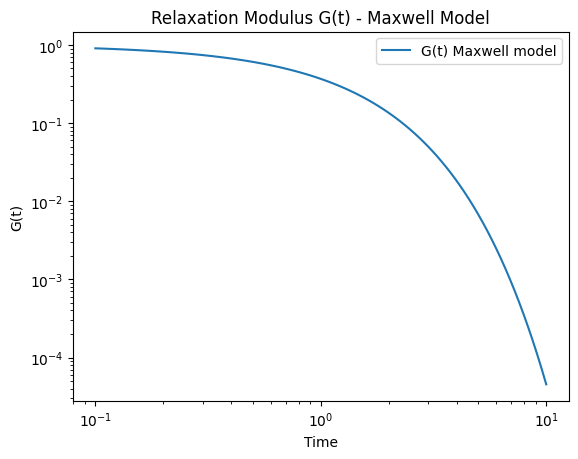

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Test of moduli function using a Maxwell model G(t) = k * exp(- (k/eta) * t)

k = 1
eta = 1.0
t = np.logspace(-1, 1, 100)
G_t = k * np.exp(- (k / eta) * t)

print(np.any(~np.isfinite(G_t))) # should be False
print("Maxwell model G(t) min, max:", G_t.min(), G_t.max())
print("Smallest and largest dt:", np.min(np.diff(t)), np.max(np.diff(t)))

# plt.loglog(t, G_t , label='G(t) Maxwell model')
plt.loglog(t, G_t , label='G(t) Maxwell model')
plt.xlabel('Time')
plt.ylabel('G(t)')
plt.title('Relaxation Modulus G(t) - Maxwell Model')
plt.legend()
plt.show()



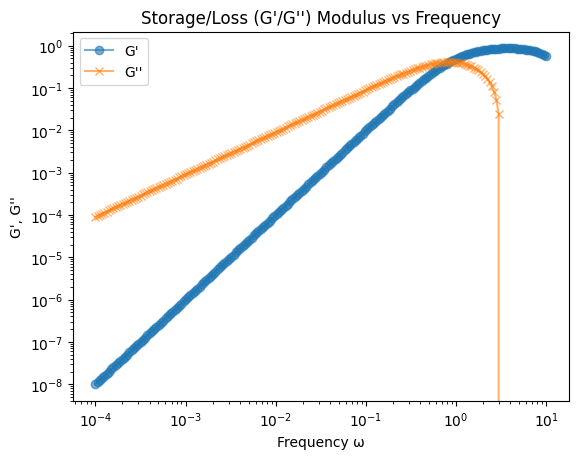

In [24]:
# t_start = 0
# t_end = 
# n data points
n = 200
omega = np.logspace(-4, 1, n)
F, Gp, Gpp = fourier_integral_moduli(t, G_t, omega)
plt.loglog(omega, Gp, marker='o', alpha=0.6, label="G'")
plt.loglog(omega, Gpp, marker='x', alpha=0.6, label="G''")
plt.xlabel('Frequency ω')
plt.ylabel("G', G''")
plt.title("Storage/Loss (G'/G'') Modulus vs Frequency")
plt.legend()
plt.show()


Due to the log spacing of the multiple-tau output, I'm going to test a trapezoid integral. The calculation above is very unstable when $\Delta t$ gets large.

In [25]:
def fourier_moduli_uneven_vec(t, G, omega):
    t = np.asarray(t)
    G = np.asarray(G)
    omega = np.atleast_1d(omega)
    
    exp_matrix = np.exp(-1j * np.outer(omega, t))  # shape (len(omega), len(t))
    F = np.trapz(G * exp_matrix, t, axis=1)
    
    Gp = -omega * F.imag
    Gpp = omega * F.real
    return F, Gp, Gpp

/tmp/ipykernel_903408/4282204912.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  F = np.trapz(G * exp_matrix, t, axis=1)


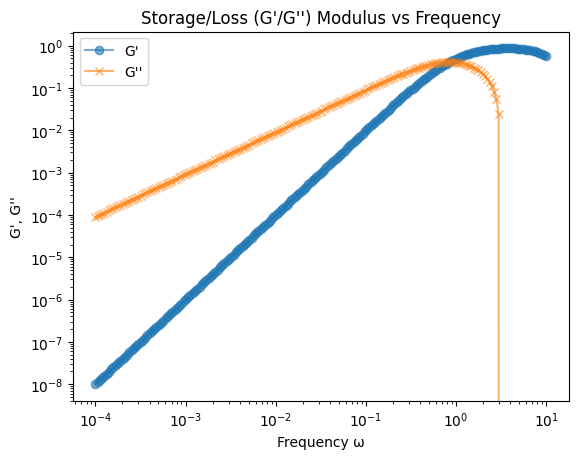

In [26]:

# n data points
n = 200
omega = np.logspace(-4, 1, n)
F, Gp, Gpp = fourier_moduli_uneven_vec(t, G_t, omega)
plt.loglog(omega, Gp, marker='o', alpha=0.6, label="G'")
plt.loglog(omega, Gpp, marker='x', alpha=0.6, label="G''")
plt.xlabel('Frequency ω')
plt.ylabel("G', G''")
plt.title("Storage/Loss (G'/G'') Modulus vs Frequency")
plt.legend()
plt.show()


## Spacing list

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_Gt_vs_time():
    try:
        file = f"data/polymer_autocorr_long.dat"
        data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['time', 'px_y', 'px_z', 'py_z', 'pxy', 'pxz', 'pyz'])
        print(f"Processing file...")


        data = data[data['time'] >= t_start]
        data = data[data['time'] <= t_end]

        data["time"] *= 0.01

        G_t = (data['pxy'] + data['pxz'] + data['pyz']) / 5.0 + \
                (data['px_y'] + data['px_z'] + data['py_z']) / 30.0

        # replace negative with NaN
        # G_t = np.where(G_t < 0, np.nan, G_t)

        G_t *= 38.891111873282**3 / (1.0 * 1.0)  # V / (kB * T)

        plt.loglog(data['time'], G_t, alpha=0.5)
        # save file as space separated values
        output_file = f"data/processed_Gt_polymer.dat"
        processed_data = pd.DataFrame({'time': data['time'], 'G_t': G_t})
        processed_data.to_csv(output_file, sep=' ', index=False)
        print(f"Processed data saved to {output_file}")
    except FileNotFoundError:
        print(f"File not found.")

Processing file...
Processed data saved to data/processed_Gt_polymer.dat


/tmp/ipykernel_2111234/2495291637.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


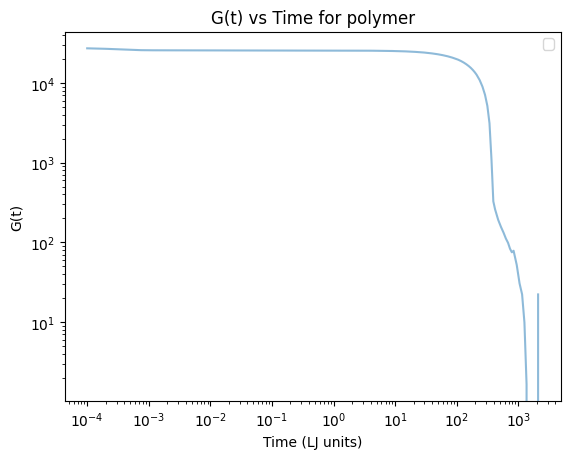

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# t_start = -np.inf
# t_end = np.inf
t_start = 0.01
t_end = 9e6

plot_Gt_vs_time()
x = np.linspace(t_start, t_end, 100)
# plt.loglog(x, x**-0.5, 'k--', label='Reference slope -0.5')

# plt.xlim([1e-1, t_end])
# plt.ylim([1e-1, 1e2])
plt.yscale('log')
plt.xlabel('Time (LJ units)')
plt.ylabel('G(t)')
plt.title('G(t) vs Time for polymer')
plt.legend()
plt.show()

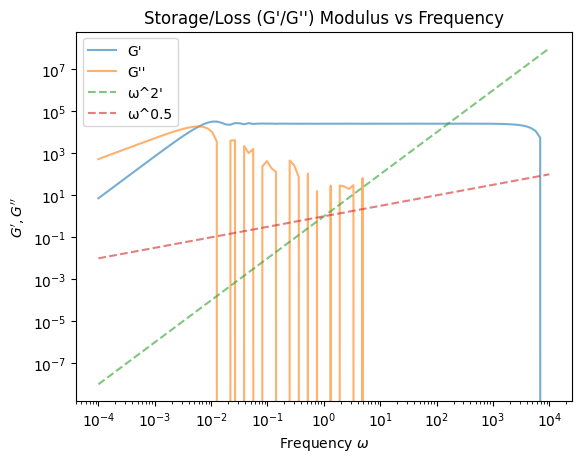

In [53]:
# apply fourier integral to each G(t) in G_list
storage_moduli = []
loss_moduli = []
n = 100
omega = np.logspace(-4, 4, n)

try:
    file = f"data/processed_Gt_polymer.dat"
    data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['time', 'G_t'])

    G_t = data['G_t'].values
    time = data['time'].values
    # print(len(time), len(G_t))
    # find NaN values and remove them
    mask = ~np.isnan(G_t)
    time = time[mask]
    G_t = G_t[mask]

    # zero pad G_t and time to next power of 2
    # N = len(G_t)
    # N_pad = 2**int(np.ceil(np.log2(N)))
    # G_t = np.pad(G_t, (0, N_pad - N), 'constant', constant_values=(0, 0))
    # time = np.pad(time, (0, N_pad - N), 'constant', constant_values=(0, time[-1] + (time[1]-time[0]) * np.arange(1, N_pad - N + 1)))  
    
except FileNotFoundError:
    print(f"File not found. Skipping.")

F, Gp, Gpp = fourier_integral_moduli(time, G_t, omega)
# print(len(omega), len(Gp), len(Gpp))
# print(Gp)
# storage_moduli.append(Gp)
# loss_moduli.append(Gpp)
plt.loglog(omega, Gp, linestyle='-', alpha=0.6, label=f"G'")
plt.loglog(omega, Gpp, linestyle='-', alpha=0.6, label=f"G''")

plt.loglog(omega, omega**2, linestyle='--', alpha=0.6, label=f"ω^2'")
plt.loglog(omega, omega**0.5, linestyle='--', alpha=0.6, label=f"ω^{0.5}")

plt.xlabel(r'Frequency $\omega$')
plt.ylabel("$G', G''$")
# plt.xlim([1e-4, 1e-1])
# plt.ylim([1e-11, 2e-6])
plt.title("Storage/Loss (G'/G'') Modulus vs Frequency")
plt.legend()
plt.show()

# Testing some autocorrelation stuff

Everything looks good, maybe it's worth just getting stress data and calculating autocorr myself

Text(0.5, 1.0, 'Gaussian Autocorrelation')

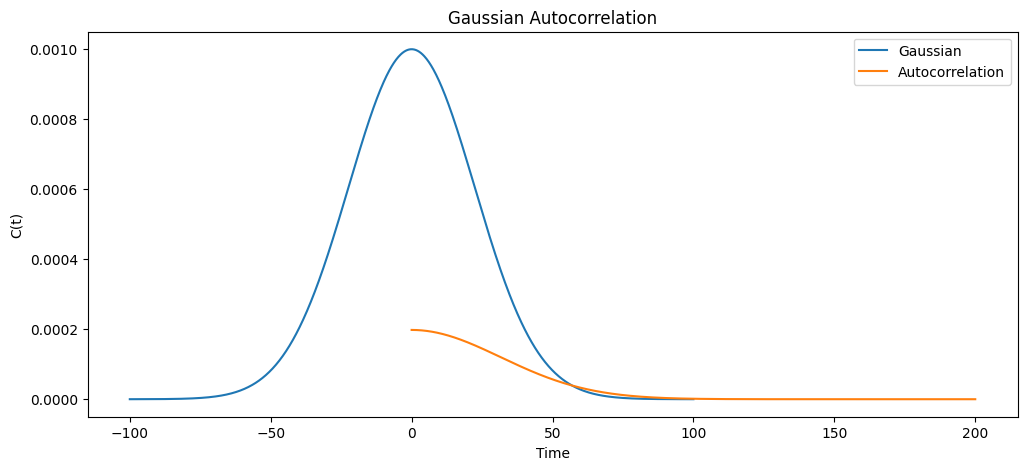

In [ ]:
gaussian = lambda t, A, tau: A * np.exp(-t**2 / tau)

x = np.linspace(-100, 100, 1000)
y = gaussian(x, A=1e-3, tau=1e3)


def autocorr(x):
    result = np.correlate(x, x, mode='full')
    return result[result.size // 2:]

autocorr_gaussian = autocorr(y)

plt.figure(figsize=(12, 5))
plt.plot(x, y, label='Gaussian')
plt.plot(np.linspace(0, 200, 1000), autocorr_gaussian, label='Autocorrelation')
plt.xlabel('Time')
plt.ylabel('C(t)')
plt.legend()
plt.title('Gaussian Autocorrelation')
plt.show()

numpy autocorrelation took 411.4359 seconds
Scipy autocorrelation took 0.0114 seconds


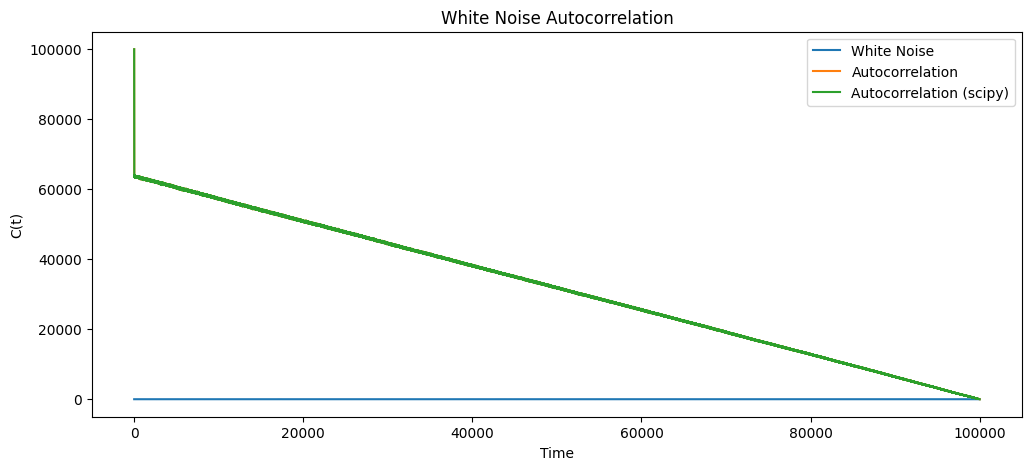

In [ ]:
# white noise
import scipy
import time


x = np.linspace(0, 100000, 100000)
y = np.abs(np.random.normal(0, 1, size=x.shape))
start = time.time()
autocorr_noise = autocorr(y)
print(f"numpy autocorrelation took {time.time() - start:.4f} seconds")
start = time.time()
autocorr_noise_scipy = scipy.signal.correlate(y, y, mode='full')[len(y)-1:]
print(f"Scipy autocorrelation took {time.time() - start:.4f} seconds")

plt.figure(figsize=(12, 5))
plt.plot(x, np.abs(y), label='White Noise')
plt.plot(np.linspace(0, 100000, 100000), np.abs(autocorr_noise), label='Autocorrelation')
plt.plot(np.linspace(0, 100000, 100000), np.abs(autocorr_noise_scipy), label='Autocorrelation (scipy)')
plt.xlabel('Time')
plt.ylabel('C(t)')
plt.legend()
plt.title('White Noise Autocorrelation')
plt.show()

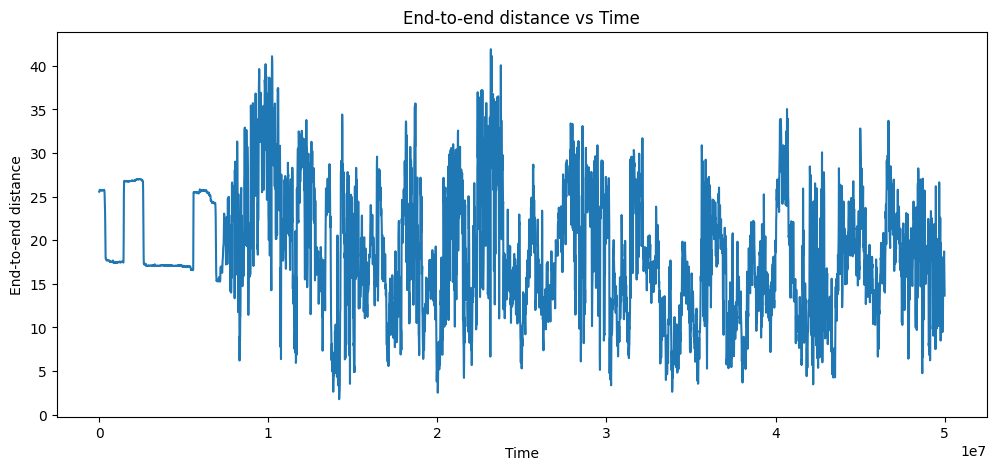

In [54]:
data = pd.read_csv("logs/endtoend_short.dat", skiprows=2, delimiter=" ", names=["time", "end2end"])

plt.figure(figsize=(12, 5))
plt.plot(data['time'], data['end2end'])
plt.xlabel('Time')
plt.ylabel('End-to-end distance')
plt.title('End-to-end distance vs Time')
plt.show()


## Let's try to calculate autocorr ourselves, instead of multiple tau, just to verify it 

(if they're obviously different, we need to take a closer look)

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal

data = pd.read_csv("data/polymer_press_long.dat", delimiter=' ', skiprows=2, index_col=False, names=['timestep', 'pressure', 'p_x', 'p_y', 'p_z', 'p_xy', 'p_xz', 'p_yz'])
display(data.head())

data['time'] = data['timestep'] * 0.005

data['p_x-y'] = data['p_x'] - data['p_y']
data['p_x-z'] = data['p_x'] - data['p_z']
data['p_y-z'] = data['p_y'] - data['p_z']

,timestep,pressure,p_x,p_y,p_z,p_xy,p_xz,p_yz
0,0,53.1367,48.9936,53.9150,56.5014,0.064606,0.342765,0.506460
1,10,53.0743,48.9507,53.7673,56.5049,-0.024001,0.295008,0.523821
2,20,53.0494,49.0158,53.6430,56.4893,-0.002824,0.443872,0.457732
3,30,53.0264,48.9088,53.7534,56.4171,0.096645,0.344448,0.450420
4,40,53.0578,48.8429,53.8193,56.5113,0.134555,0.310466,0.509238


In [ ]:
def autocorr(x):
    # result = np.correlate(x, x, mode='full')
    # return result[result.size // 2:]
    return scipy.signal.correlate(x, x, mode='full')[len(x)-1:]

G_t_scipy = (autocorr(data['p_xy'].values) + autocorr(data['p_xz'].values) + autocorr(data['p_yz'].values)) / 5.0 + \
      (autocorr(data['p_x-y'].values) + autocorr(data['p_x-z'].values) + autocorr(data['p_y-z'].values)) / 30.0


In [26]:
file = f"data/polymer_autocorr_long.dat"
data_multitau = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['time', 'px_y', 'px_z', 'py_z', 'pxy', 'pxz', 'pyz'])
G_t_multitau = (data_multitau['pxy'] + data_multitau['pxz'] + data_multitau['pyz']) / 5.0 + \
                (data_multitau['px_y'] + data_multitau['px_z'] + data_multitau['py_z']) / 30.0


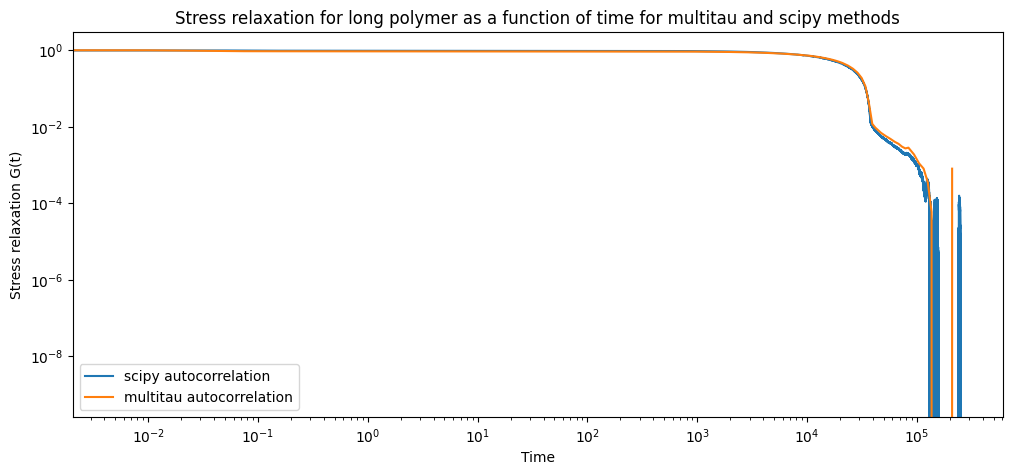

In [33]:
plt.figure(figsize=(12, 5))
normalize = lambda x: (x[0] + x[1] + x[2]) / 3
plt.loglog(data['time'], G_t_scipy/normalize(G_t_scipy) , label='scipy autocorrelation')
plt.loglog(data_multitau['time'], G_t_multitau/normalize(G_t_multitau) , label='multitau autocorrelation')
plt.xlabel('Time')
plt.ylabel('Stress relaxation G(t)')
plt.title('Stress relaxation for long polymer as a function of time for multitau and scipy methods')
plt.legend()
plt.show()

Okay yes, this is definitely verifying that multitau and the pressure calculation method is the same, up to some statistical noise/error at large times. As long as we have approx. the same drop off it should be fine, and we shouldn't calculate anything using the drop off anyways. Calculations should be done on th decaying curve or the plateaus.

## Mean Squared Internal Displacement

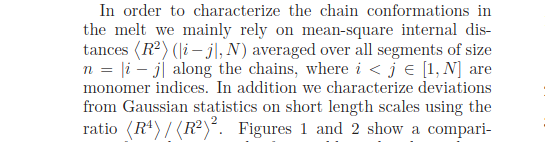



Taking these from dump files, we need to know how many lines are in each frame. The monomer indices are also not included, so we need to calculate these from the atom IDs and the molecule IDs.

In [7]:
# read first 4 lines of file to get total number of atoms
with open("data/equilibration.lammpstrj", 'r') as f:
    header = [next(f) for _ in range(4)]
    for line in header:
        print(line.strip())

n_atoms = int(header[3])
print(n_atoms)

ITEM: TIMESTEP
0
ITEM: NUMBER OF ATOMS
80000
80000


We also need to set the chain length and box dimensions for monomer index and minimum image calculations 

In [ ]:
chain_length = 200
box_size = 45.4873203905191 # assuming cube box